# 2.4 — Matrices, at the computer

Worksheet first. Then the payoff: you'll *watch* a 2×2 matrix grab an entire shape
and transform it — the thing no textbook picture quite conveys.

In [1]:
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
from plots import axes_through_origin

## 1. View one: the data table

Rows = samples, columns = features. New syntax below: `M[0]` grabs a row,
`M[:, 2]` grabs a column (`:` = "all rows", then "column 2").

In [2]:
# Three houses: (bedrooms, bathrooms, land m2)
houses = np.array([[3, 2,  650],
                   [4, 2,  700],
                   [9, 7, 4000]])

print("shape        =", houses.shape, " <- (rows, columns) — 3 houses, 3 features")
print("houses[0]    =", houses[0], "      <- row 0: the first house's vector")
print("houses[:, 2] =", houses[:, 2], "<- column 2: everyone's land size")
print("mean land    =", houses[:, 2].mean(), " <- stats on a feature = stats on a column")

shape        = (3, 3)  <- (rows, columns) — 3 houses, 3 features
houses[0]    = [  3   2 650]       <- row 0: the first house's vector
houses[:, 2] = [ 650  700 4000] <- column 2: everyone's land size
mean land    = 1783.3333333333333  <- stats on a feature = stats on a column


## 2. View two: the transformation machine

A shape is just a bag of vectors — one per corner. Store the corners as *columns* of a 2×N array,
and one `M @ shape` transforms **every corner at once**. Below: a little house shape, fed through
three different machines. Before running, predict each from its matrix.

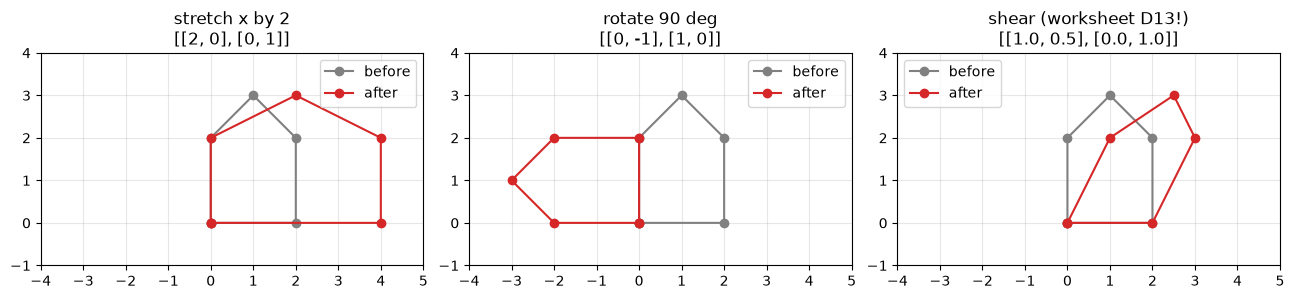

In [3]:
# Corners of a house shape, one corner per COLUMN: row 0 = all the x's, row 1 = all the y's.
house = np.array([[0, 2, 2, 1, 0, 0],     # x-coordinates
                  [0, 0, 2, 3, 2, 0]])    # y-coordinates

machines = {
    "stretch x by 2":            np.array([[2, 0], [0, 1]]),
    "rotate 90 deg":             np.array([[0, -1], [1, 0]]),
    "shear (worksheet D13!)":    np.array([[1, 0.5], [0, 1]]),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (name, M) in zip(axes, machines.items()):
    new = M @ house                        # ONE multiplication transforms every corner
    ax.plot(house[0], house[1], "o-", color="grey", label="before")
    ax.plot(new[0], new[1], "o-", color="C3", label="after")
    ax.set_title(f"{name}\n{M.tolist()}")
    ax.grid(alpha=0.3); ax.set_aspect("equal"); ax.legend()
    ax.set_xlim(-4, 5); ax.set_ylim(-1, 4)
plt.tight_layout(); plt.show()

M @ [1,0] = [2. 0.]   <- exactly column 0 of M
M @ [0,1] = [0.5 1. ]   <- exactly column 1 of M


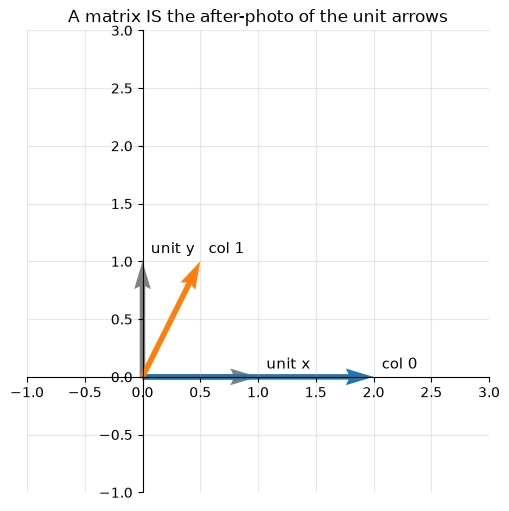

In [4]:
# The secret decoder, verified: a matrix's COLUMNS are where the unit arrows land.
M = np.array([[2, 0.5],
              [0, 1.0]])

print("M @ [1,0] =", M @ np.array([1, 0]), "  <- exactly column 0 of M")
print("M @ [0,1] =", M @ np.array([0, 1]), "  <- exactly column 1 of M")

ax = axes_through_origin(xlim=(-1, 3), ylim=(-1, 3))
for v, c, lab in [([1, 0], "grey", "unit x"), ([0, 1], "grey", "unit y"),
                  (M @ np.array([1, 0]), "C0", "col 0"), (M @ np.array([0, 1]), "C1", "col 1")]:
    ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1,
              color=c, width=0.012)
    ax.annotate(lab, (v[0], v[1]), textcoords="offset points", xytext=(6, 6), fontsize=11)
ax.set_title("A matrix IS the after-photo of the unit arrows")
plt.show()

In [5]:
# YOUR TURN
# 1) Verify worksheet Part B with @ — one is done:
print(np.array([[2, 0], [0, 3]]) @ np.array([1, 1]))    # B5a

# 2) Worksheet Part B7: you designed three machines with the column decoder
#    (double, flip left-right, squash flat). Test each on the house shape —
#    copy the plotting cell above and swap in YOUR matrices. Did each do what you claimed?

# 3) Worksheet D11: build your do-nothing matrix and confirm  I @ house  is unchanged.
#    (numpy spells it np.eye(2) — check yours matches.)

# 4) Free play: find a matrix that turns the house upside-down WITHOUT flipping it left-right.

[2 3]


## 3. 🌀 Where this goes

That `M @ house` move — one matrix transforming a whole cloud of vectors at once — **is** a
neural network layer. Replace the house's 6 corners with a batch of 10,000 images-as-vectors,
replace the 2×2 with a learned weight matrix, and you've described most of the computation in
deep learning. Training just means: *adjust the machine's numbers until the after-photo is useful.*

---
*Photograph your worksheet into `scans/inbox/`. Next: 2.5 — what happens when machines feed
machines, and why matrix multiplication has that weird rule. (Spoiler: it isn't weird.)*